# Experiment Visualization for Report Writing

This notebook is designed around the current direction of the project: **showing symmetry-based parameter sharing as an inductive bias** rather than as a mere compression trick.

The notebook focuses on three report-friendly questions.

1. Does symmetry-aware parameter sharing improve **sample efficiency**?
2. Does it reduce **symmetry error** and produce a cleaner hypothesis space?
3. Does it remain competitive or advantageous under **parameter constraints**?

To support those claims, the notebook creates:

- DeepSet summary tables, heatmaps, and parameter-efficiency plots
- Graph experiment aggregations from saved logs and validation-loss heatmaps
- 3Body quantitative comparisons and qualitative rollout visualizations

It also writes intermediate summary tables into `figures/summary_tables` so they can be reused in the report.

In [1]:
from pathlib import Path
import re
import json
import math
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

ROOT = Path.cwd()
assert ROOT.name == 'Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner', (
    'Please run this notebook from the Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner directory.'
)

FIG_DIR = ROOT / 'figures'
TABLE_DIR = FIG_DIR / 'summary_tables'
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [2]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def save_table(df, name):
    csv_path = TABLE_DIR / f'{name}.csv'
    df.to_csv(csv_path, index=False)
    print(f'Saved table -> {csv_path}')

def save_figure(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight', dpi=220)
    print(f'Saved figure -> {path}')

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

shared_palette = {
    'shared': '#1f77b4',
    'vanilla': '#d62728',
    'symmetric': '#1f77b4',
    'vanilla (data augmented)': '#ff7f0e',
    'symmetric (data augmented)': '#2ca02c',
    'vanilla_aug': '#ff7f0e',
    'shared_aug': '#2ca02c'
}

task_titles = {
    'DeepSet': 'Task 1: Permutation-Invariant Set Function',
    'Graph': 'Task 2: Graph Classification',
    '3Body': 'Task 3: Symmetric Physical System Prediction'
}

In [3]:
# ------------------------------------------------------------------
# Task 1: DeepSet aggregation and visualization
# ------------------------------------------------------------------
deep_result = load_pickle(ROOT / 'DeepSetProblem' / 'total_result.pkl')

deep_rows = []
for n_block, by_size in deep_result.items():
    for data_size, metrics in by_size.items():
        deep_rows.append({
            'task': 'DeepSet',
            'n_block': int(n_block),
            'data_size': int(data_size),
            'vanilla_loss': float(metrics['vanilla_loss']),
            'shared_loss': float(metrics['shared_loss']),
            'vanilla_symmetry': float(metrics['vanilla_symmetry']),
            'shared_symmetry': float(metrics['shared_symmetry']),
            'vanilla_size': int(metrics['vanilla_size']),
            'shared_size': int(metrics['shared_size']),
        })

deep_df = pd.DataFrame(deep_rows).sort_values(['n_block', 'data_size']).reset_index(drop=True)
deep_df['loss_gain'] = deep_df['vanilla_loss'] - deep_df['shared_loss']
deep_df['symmetry_gain'] = deep_df['vanilla_symmetry'] - deep_df['shared_symmetry']
deep_df['size_ratio'] = deep_df['vanilla_size'] / deep_df['shared_size']
save_table(deep_df, 'deepset_summary')
deep_df.head()

Saved table -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/summary_tables/deepset_summary.csv


,task,n_block,data_size,vanilla_loss,shared_loss,vanilla_symmetry,shared_symmetry,vanilla_size,shared_size,loss_gain,symmetry_gain,size_ratio
0,DeepSet,1,50,1.216982,1.913904,0.0,0.0,345,651,-0.696923,0.0,0.529954
1,DeepSet,1,100,0.317138,0.828948,0.0,0.0,345,651,-0.511811,0.0,0.529954
2,DeepSet,1,500,0.009295,0.008387,0.0,0.0,345,651,0.000907,0.0,0.529954
3,DeepSet,1,1000,0.016081,0.002988,0.0,0.0,345,651,0.013094,0.0,0.529954
4,DeepSet,1,5000,0.017934,0.022836,0.0,0.0,345,651,-0.004902,0.0,0.529954


In [4]:
deep_df

,task,n_block,data_size,vanilla_loss,shared_loss,vanilla_symmetry,shared_symmetry,vanilla_size,shared_size,loss_gain,symmetry_gain,size_ratio
0,DeepSet,1,50,1.216982,1.913904,0.000000,0.000000e+00,345,651,-0.696923,0.000000,0.529954
1,DeepSet,1,100,0.317138,0.828948,0.000000,0.000000e+00,345,651,-0.511811,0.000000,0.529954
2,DeepSet,1,500,0.009295,0.008387,0.000000,0.000000e+00,345,651,0.000907,0.000000,0.529954
3,DeepSet,1,1000,0.016081,0.002988,0.000000,0.000000e+00,345,651,0.013094,0.000000,0.529954
4,DeepSet,1,5000,0.017934,0.022836,0.000000,0.000000e+00,345,651,-0.004902,0.000000,0.529954
5,DeepSet,1,10000,0.025739,0.702096,0.000000,0.000000e+00,345,651,-0.676357,0.000000,0.529954
6,DeepSet,2,50,0.880284,0.212638,0.091724,0.000000e+00,1297,651,0.667645,0.091724,1.992320
7,DeepSet,2,100,0.917307,0.452789,0.070267,0.000000e+00,1297,651,0.464517,0.070267,1.992320
8,DeepSet,2,500,0.075105,0.133459,0.006363,0.000000e+00,1297,651,-0.058354,0.006363,1.992320
9,DeepSet,2,1000,0.088697,0.150172,0.009627,0.000000e+00,1297,651,-0.061475,0.009627,1.992320


Saved figure -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/deepset_curves.png


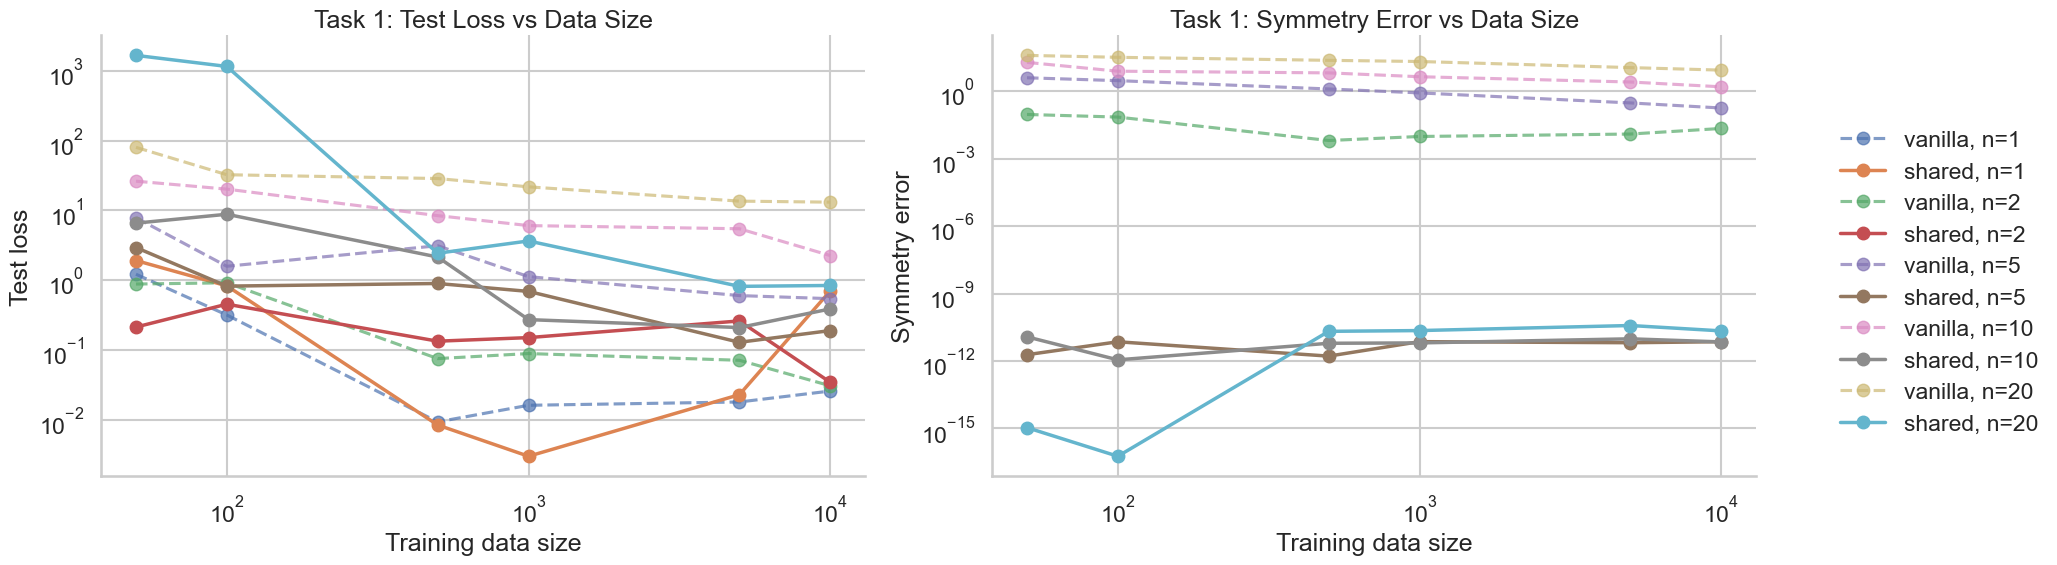

Saved figure -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/deepset_heatmaps.png


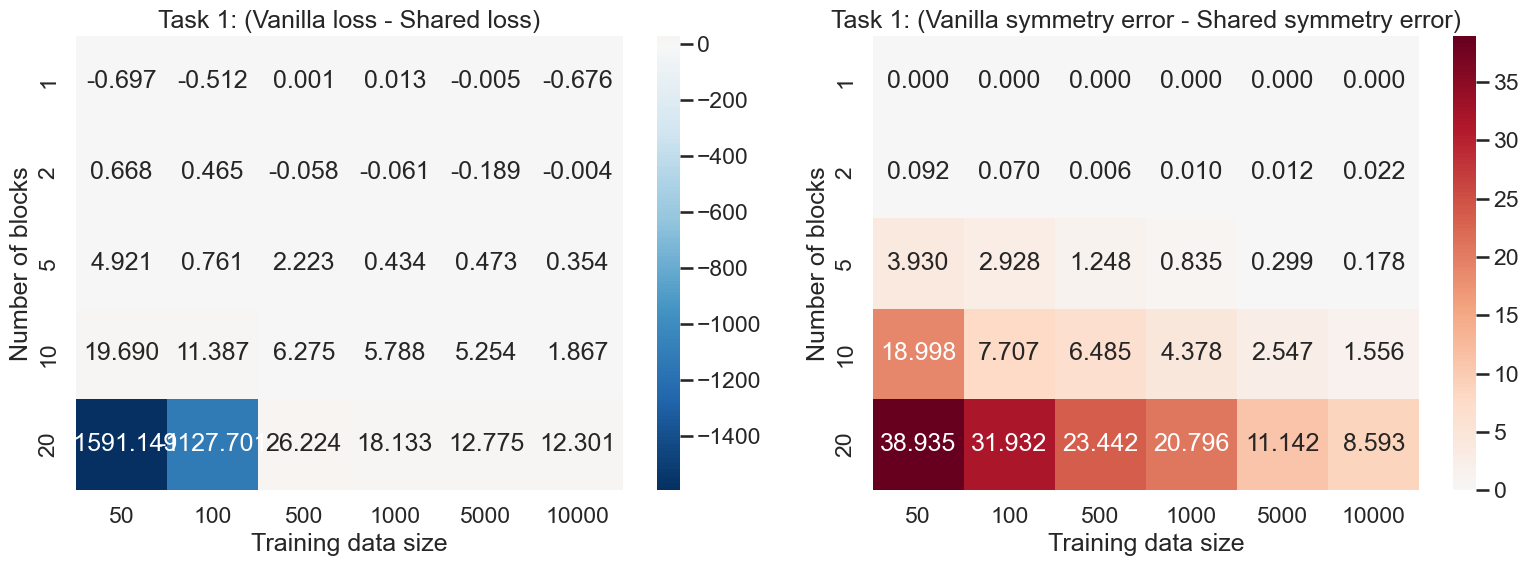

Saved figure -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/deepset_parameter_efficiency.png


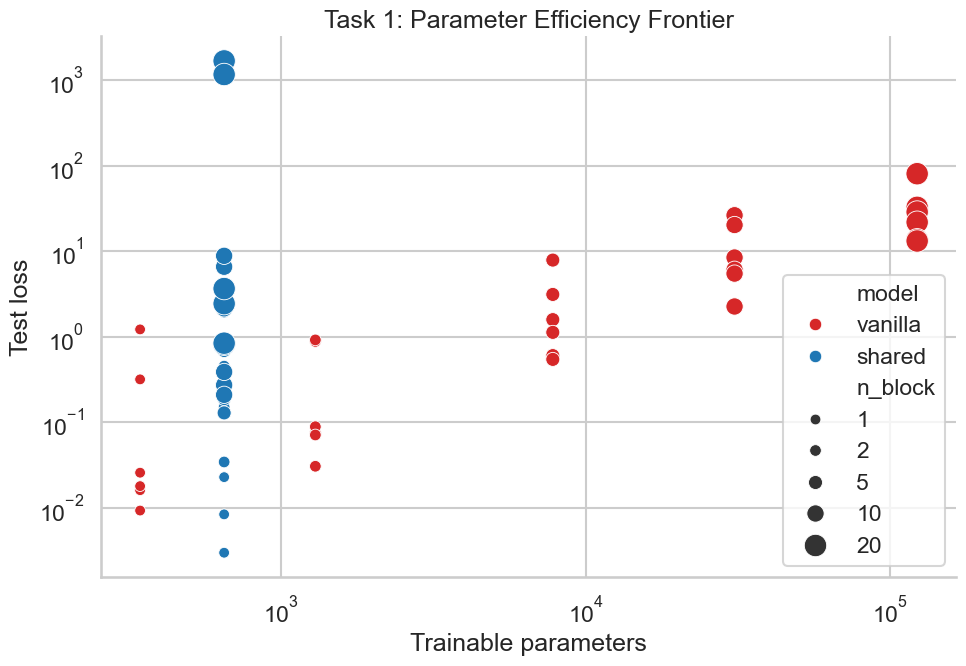

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for n_block in sorted(deep_df['n_block'].unique()):
    sub = deep_df[deep_df['n_block'] == n_block]
    axes[0].plot(sub['data_size'], sub['vanilla_loss'], marker='o', linestyle='--', alpha=0.7, label=f'vanilla, n={n_block}')
    axes[0].plot(sub['data_size'], sub['shared_loss'], marker='o', linewidth=2.5, label=f'shared, n={n_block}')
    axes[1].plot(sub['data_size'], sub['vanilla_symmetry'], marker='o', linestyle='--', alpha=0.7, label=f'vanilla, n={n_block}')
    axes[1].plot(sub['data_size'], sub['shared_symmetry'], marker='o', linewidth=2.5, label=f'shared, n={n_block}')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Task 1: Test Loss vs Data Size')
axes[0].set_xlabel('Training data size')
axes[0].set_ylabel('Test loss')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Task 1: Symmetry Error vs Data Size')
axes[1].set_xlabel('Training data size')
axes[1].set_ylabel('Symmetry error')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
save_figure('deepset_curves.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
loss_heat = deep_df.pivot(index='n_block', columns='data_size', values='loss_gain')
sym_heat = deep_df.pivot(index='n_block', columns='data_size', values='symmetry_gain')
sns.heatmap(loss_heat, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Task 1: (Vanilla loss - Shared loss)')
axes[0].set_xlabel('Training data size')
axes[0].set_ylabel('Number of blocks')
sns.heatmap(sym_heat, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Task 1: (Vanilla symmetry error - Shared symmetry error)')
axes[1].set_xlabel('Training data size')
axes[1].set_ylabel('Number of blocks')
plt.tight_layout()
save_figure('deepset_heatmaps.png')
plt.show()

scatter_rows = []
for _, row in deep_df.iterrows():
    scatter_rows.append({'model': 'vanilla', 'n_block': row['n_block'], 'data_size': row['data_size'], 'params': row['vanilla_size'], 'test_loss': row['vanilla_loss']})
    scatter_rows.append({'model': 'shared', 'n_block': row['n_block'], 'data_size': row['data_size'], 'params': row['shared_size'], 'test_loss': row['shared_loss']})
scatter_df = pd.DataFrame(scatter_rows)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_df,
    x='params',
    y='test_loss',
    hue='model',
    size='n_block',
    sizes=(60, 260),
    palette=shared_palette,
)
plt.xscale('log')
plt.yscale('log')
plt.title('Task 1: Parameter Efficiency Frontier')
plt.xlabel('Trainable parameters')
plt.ylabel('Test loss')
plt.tight_layout()
save_figure('deepset_parameter_efficiency.png')
plt.show()

In [6]:
# ------------------------------------------------------------------
# Task 2: Graph aggregate-result visualization
# ------------------------------------------------------------------
graph_total_path = ROOT / 'GraphProblem' / 'total_result.pkl'
graph_total = load_pickle(graph_total_path)

graph_rows = []
for width_tag, by_size in graph_total.items():
    for data_size, by_model in by_size.items():
        for model_name, metrics in by_model.items():
            graph_rows.append({
                'task': 'Graph',
                'width_tag': int(width_tag),
                'data_size': int(data_size),
                'model': model_name,
                'loss': float(metrics['loss']),
                'acc': float(metrics['acc']),
                'sym_error': float(metrics['sym_error']),
            })

graph_df = pd.DataFrame(graph_rows).sort_values(['width_tag', 'data_size', 'model']).reset_index(drop=True)
graph_df['log10_sym_error'] = np.log10(np.clip(graph_df['sym_error'], 1e-16, None))

rename_map = {
    'symmetric': 'shared',
    'vanilla': 'vanilla',
    'symmetric (data augmented)': 'shared_aug',
    'vanilla (data augmented)': 'vanilla_aug',
}
graph_df['model_key'] = graph_df['model'].map(rename_map)

graph_mean_df = (
    graph_df.groupby('model', as_index=False)[['loss', 'acc', 'sym_error', 'log10_sym_error']]
    .mean()
    .sort_values('loss')
)

graph_pair_df = graph_df.pivot_table(index=['width_tag', 'data_size'], columns='model', values=['loss', 'acc', 'sym_error'])
graph_pair_df.columns = ['__'.join(col) for col in graph_pair_df.columns]
graph_pair_df = graph_pair_df.reset_index()
graph_pair_df['loss_gain_shared_vs_vanilla'] = graph_pair_df['loss__vanilla'] - graph_pair_df['loss__symmetric']
graph_pair_df['loss_gain_sharedaug_vs_vanillaaug'] = graph_pair_df['loss__vanilla (data augmented)'] - graph_pair_df['loss__symmetric (data augmented)']
graph_pair_df['acc_gain_shared_vs_vanilla'] = graph_pair_df['acc__symmetric'] - graph_pair_df['acc__vanilla']
graph_pair_df['acc_gain_sharedaug_vs_vanillaaug'] = graph_pair_df['acc__symmetric (data augmented)'] - graph_pair_df['acc__vanilla (data augmented)']

save_table(graph_df, 'graph_total_summary')
save_table(graph_mean_df, 'graph_model_means')
save_table(graph_pair_df, 'graph_pairwise_gains')
graph_df.head(12)

Saved table -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/summary_tables/graph_log_summary.csv
Saved table -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/summary_tables/graph_valid_gain_summary.csv


model,width_tag,data_size,shared,vanilla,valid_gain
0,2,500,0.552527,0.654783,0.102256
1,2,1500,0.629256,0.658889,0.029633
2,2,4110,0.665327,0.639310,-0.026018
3,3,500,0.616371,0.692132,0.075760
4,3,1500,0.623744,0.651118,0.027374
5,3,4110,0.609839,0.649845,0.040006
6,4,500,22.683313,0.685524,-21.997789
7,4,1500,39.141069,0.683980,-38.457089
8,4,4110,0.816037,0.628755,-0.187283
9,5,500,0.664748,0.667003,0.002255


NameError: name 'graph_mean_df' is not defined

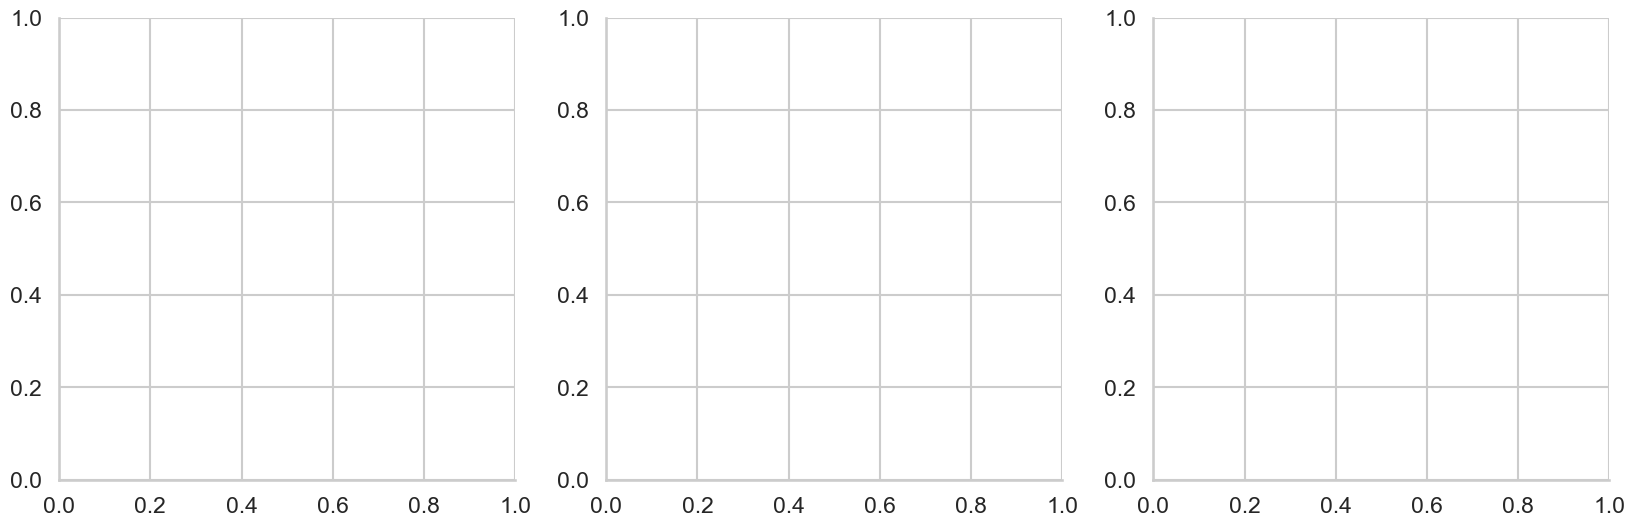

In [11]:
graph_model_order = [
    'vanilla',
    'vanilla (data augmented)',
    'symmetric',
    'symmetric (data augmented)',
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=graph_mean_df, x='model', y='loss', hue='model', dodge=False,
            order=graph_model_order, palette=[shared_palette[rename_map[m]] for m in graph_model_order], ax=axes[0])
axes[0].set_title('Task 2: Mean Test Loss')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Loss')
axes[0].tick_params(axis='x', rotation=20)
if axes[0].legend_ is not None:
    axes[0].legend_.remove()

sns.barplot(data=graph_mean_df, x='model', y='acc', hue='model', dodge=False,
            order=graph_model_order, palette=[shared_palette[rename_map[m]] for m in graph_model_order], ax=axes[1])
axes[1].set_title('Task 2: Mean Test Accuracy')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=20)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

sns.barplot(data=graph_mean_df, x='model', y='log10_sym_error', hue='model', dodge=False,
            order=graph_model_order, palette=[shared_palette[rename_map[m]] for m in graph_model_order], ax=axes[2])
axes[2].set_title('Task 2: Mean log10 Symmetry Error')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('log10 symmetry error')
axes[2].tick_params(axis='x', rotation=20)
if axes[2].legend_ is not None:
    axes[2].legend_.remove()

plt.tight_layout()
save_figure('graph_overview_bars.png')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, width_tag in zip(axes, sorted(graph_df['width_tag'].unique())):
    sub = graph_df[graph_df['width_tag'] == width_tag]
    for model_name in graph_model_order:
        line = sub[sub['model'] == model_name].sort_values('data_size')
        ax.plot(line['data_size'], line['acc'], marker='o', linewidth=2,
                label=model_name, color=shared_palette[rename_map[model_name]])
    ax.set_title(f'width={width_tag}')
    ax.set_xlabel('Training data size')
    ax.set_ylabel('Accuracy')
    ax.set_xscale('log')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle('Task 2: Accuracy by Data Size and Model Width', y=1.03)
plt.tight_layout()
save_figure('graph_accuracy_curves.png')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for col, model_name in enumerate(graph_model_order):
    sub = graph_df[graph_df['model'] == model_name]
    loss_heat = sub.pivot(index='width_tag', columns='data_size', values='loss')
    sym_heat = sub.pivot(index='width_tag', columns='data_size', values='log10_sym_error')
    sns.heatmap(loss_heat, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0, col])
    axes[0, col].set_title(f'{model_name}\nLoss')
    axes[0, col].set_xlabel('Training data size')
    axes[0, col].set_ylabel('Width tag')
    sns.heatmap(sym_heat, annot=True, fmt='.2f', cmap='magma_r', ax=axes[1, col])
    axes[1, col].set_title(f'{model_name}\nlog10 Symmetry Error')
    axes[1, col].set_xlabel('Training data size')
    axes[1, col].set_ylabel('Width tag')
plt.tight_layout()
save_figure('graph_heatmaps.png')
plt.show()

graph_pair_df[['width_tag', 'data_size', 'loss_gain_shared_vs_vanilla', 'loss_gain_sharedaug_vs_vanillaaug', 'acc_gain_shared_vs_vanilla', 'acc_gain_sharedaug_vs_vanillaaug']]

In [8]:
# ------------------------------------------------------------------
# Task 3: 3Body aggregation, evaluation, and rollout visualization
# ------------------------------------------------------------------
class EquivariantLinear2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        scale = 1.0 / np.sqrt(in_channels * 3)
        self.A = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.B = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.C = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.D = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.E = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.bias_sym = nn.Parameter(torch.zeros(out_channels))
        self.bias_third = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        row1 = torch.cat([self.A, self.B, self.C], dim=1)
        row2 = torch.cat([self.B, self.A, self.C], dim=1)
        row3 = torch.cat([self.D, self.D, self.E], dim=1)
        W = torch.cat([row1, row2, row3], dim=0)
        b = torch.cat([self.bias_sym, self.bias_sym, self.bias_third], dim=0)
        return x @ W.t() + b

def build_vanilla_from_state_dict(state_dict):
    linear_keys = sorted({int(k.split('.')[0]) for k in state_dict if k.endswith('weight')})
    layers = []
    for idx, key in enumerate(linear_keys):
        weight = state_dict[f'{key}.weight']
        out_dim, in_dim = weight.shape
        layers.append(nn.Linear(in_dim, out_dim))
        if idx < len(linear_keys) - 1:
            layers.append(nn.ReLU())
    model = nn.Sequential(*layers)
    model.load_state_dict(state_dict)
    return model

def build_equivariant_from_state_dict(state_dict):
    layer_keys = sorted({int(k.split('.')[0]) for k in state_dict if k.endswith('.A')})
    layers = []
    for idx, key in enumerate(layer_keys):
        out_dim, in_dim = state_dict[f'{key}.A'].shape
        layers.append(EquivariantLinear2D(in_dim, out_dim))
        if idx < len(layer_keys) - 1:
            layers.append(nn.ReLU())
    model = nn.Sequential(*layers)
    model.load_state_dict(state_dict)
    return model

def architecture_signature(state_dict):
    parts = []
    if any(k.endswith('.A') for k in state_dict):
        layer_keys = sorted({int(k.split('.')[0]) for k in state_dict if k.endswith('.A')})
        for key in layer_keys:
            out_dim, in_dim = state_dict[f'{key}.A'].shape
            parts.append(f'E({in_dim}->{out_dim})')
    else:
        layer_keys = sorted({int(k.split('.')[0]) for k in state_dict if k.endswith('weight')})
        for key in layer_keys:
            out_dim, in_dim = state_dict[f'{key}.weight'].shape
            parts.append(f'L({in_dim}->{out_dim})')
    return ' - '.join(parts)

def swap_first_two_particles(x):
    x = x.clone()
    x[..., 0:4], x[..., 4:8] = x[..., 4:8].clone(), x[..., 0:4].clone()
    return x

def symmetry_error_3body(model, X, batch_size=512):
    model.eval()
    values = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = X[start:start+batch_size]
            out1 = model(batch)
            out2 = model(swap_first_two_particles(batch))
            out2_swapped = swap_first_two_particles(out2)
            err = ((out1 - out2_swapped) ** 2).mean(dim=-1)
            values.append(err.cpu())
    return torch.cat(values).mean().item()

X_test_3body = torch.load(ROOT / '3BodyProblem' / 'data' / 'X_test.pt', map_location=device)
Y_test_3body = torch.load(ROOT / '3BodyProblem' / 'data' / 'Y_test.pt', map_location=device)

three_body_models = {}
three_body_rows = []
for model_path in sorted((ROOT / '3BodyProblem' / 'models').glob('*_0408.pt')):
    name = model_path.stem
    state_dict = torch.load(model_path, map_location=device)
    if 'equiv' in name:
        model = build_equivariant_from_state_dict(state_dict)
    else:
        model = build_vanilla_from_state_dict(state_dict)
    three_body_models[name] = model
    model.to(device)
    model.eval()
    with torch.no_grad():
        pred = model(X_test_3body)
        test_loss = nn.MSELoss()(pred, Y_test_3body).item()
    sym_err = symmetry_error_3body(model, X_test_3body)
    family = 'shared' if 'equiv' in name else 'vanilla'
    variant = 'checkpoint_1' if 'model1' in name else 'checkpoint_2'
    three_body_rows.append({
        'task': '3Body',
        'name': name,
        'model_family': family,
        'variant': variant,
        'test_loss': test_loss,
        'symmetry_error': sym_err,
        'params': count_parameters(model),
        'architecture': architecture_signature(state_dict),
    })

three_body_df = pd.DataFrame(three_body_rows).sort_values(['variant', 'model_family']).reset_index(drop=True)
save_table(three_body_df, 'three_body_summary')
three_body_df

Saved table -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/summary_tables/three_body_summary.csv


,task,name,model_family,variant,test_loss,symmetry_error,params,architecture
0,3Body,equiv_model1_0408,shared,checkpoint_1,1.984676,2.843416e-12,1992,E(4->16) - E(16->16) - E(16->4)
1,3Body,vanilla_model1_0408,vanilla,checkpoint_1,0.725703,2.461715e+00,3564,L(12->48) - L(48->48) - L(48->12)
2,3Body,equiv_model2_0408,shared,checkpoint_2,1.984676,2.843416e-12,1992,E(4->16) - E(16->16) - E(16->4)
3,3Body,vanilla_model2_0408,vanilla,checkpoint_2,0.725703,2.461715e+00,3564,L(12->48) - L(48->48) - L(48->12)


Saved figure -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/3body_summary.png


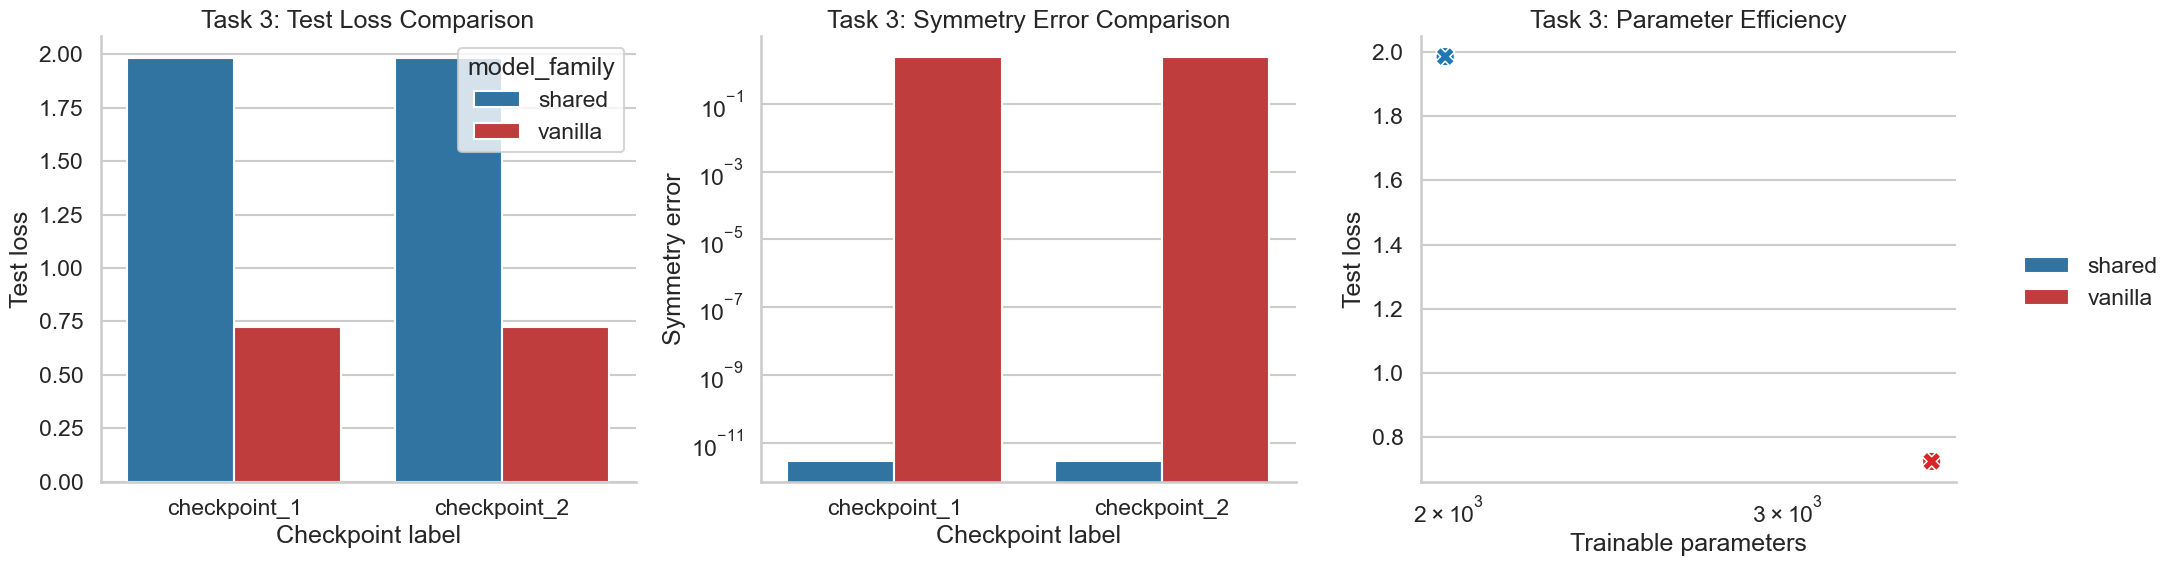

contiguous segment: (0, 499)
Saved figure -> /Users/sinikar/Desktop/2026/10.졸업연구/Repository/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/figures/3body_rollout.png


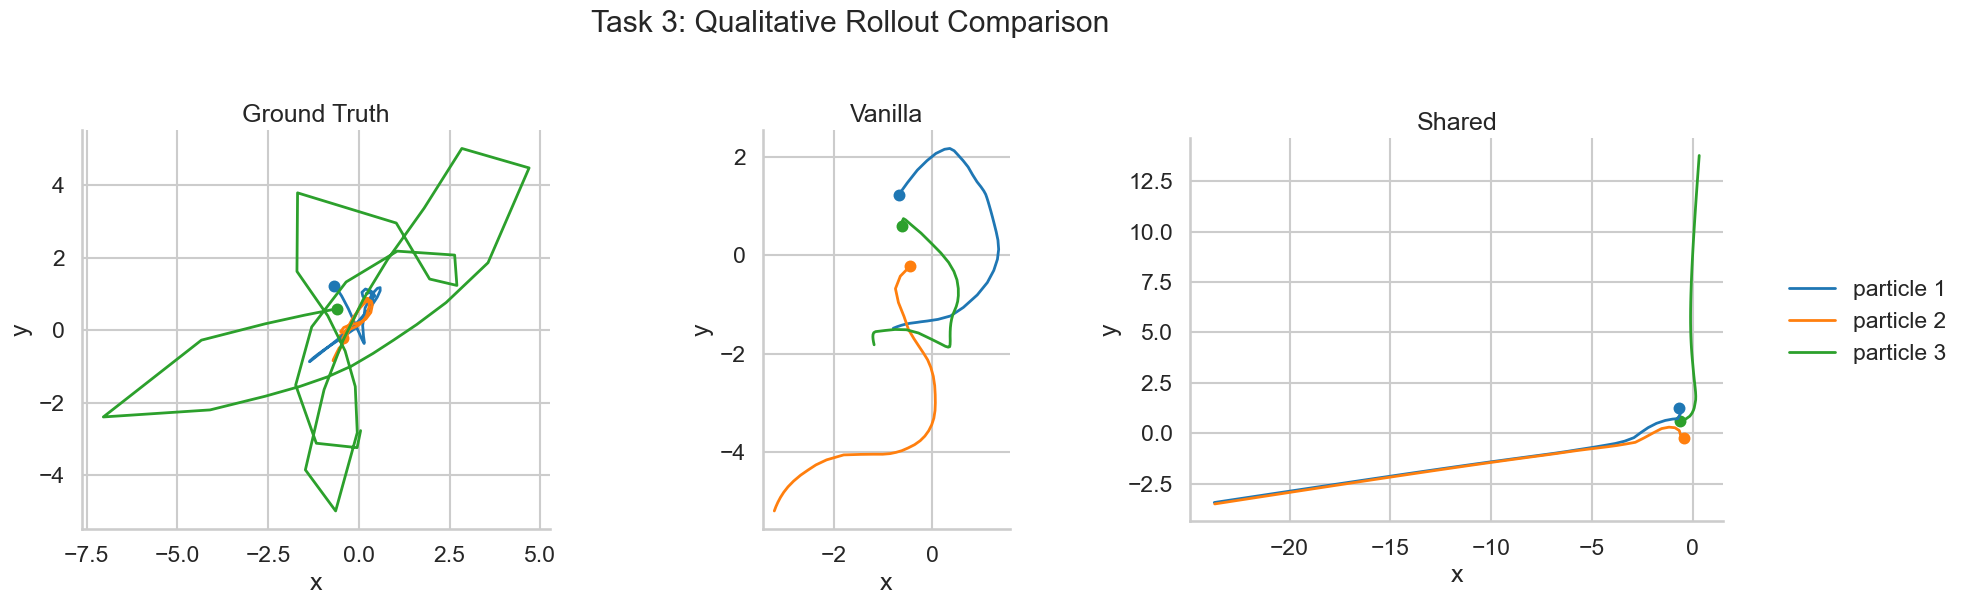

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=three_body_df, x='variant', y='test_loss', hue='model_family', palette=shared_palette, ax=axes[0])
axes[0].set_title('Task 3: Test Loss Comparison')
axes[0].set_xlabel('Checkpoint label')
axes[0].set_ylabel('Test loss')

sns.barplot(data=three_body_df, x='variant', y='symmetry_error', hue='model_family', palette=shared_palette, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Task 3: Symmetry Error Comparison')
axes[1].set_xlabel('Checkpoint label')
axes[1].set_ylabel('Symmetry error')

sns.scatterplot(data=three_body_df, x='params', y='test_loss', hue='model_family', style='variant', s=180, palette=shared_palette, ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_title('Task 3: Parameter Efficiency')
axes[2].set_xlabel('Trainable parameters')
axes[2].set_ylabel('Test loss')

for ax in axes[1:]:
    if ax.legend_ is not None:
        ax.legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
save_figure('3body_summary.png')
plt.show()

def find_contiguous_segment(X, Y, min_length=20, atol=1e-6):
    current_start = 0
    current_length = 1
    best = (0, 1)
    for i in range(len(X) - 1):
        if torch.allclose(Y[i], X[i+1], atol=atol, rtol=0):
            current_length += 1
        else:
            if current_length > best[1]:
                best = (current_start, current_length)
            current_start = i + 1
            current_length = 1
    if current_length > best[1]:
        best = (current_start, current_length)
    if best[1] < min_length:
        return None
    return best

segment = find_contiguous_segment(X_test_3body, Y_test_3body, min_length=15)
print('contiguous segment:', segment)

if segment is not None:
    start, length = segment
    rollout_len = min(length, 40)
    gt_states = [X_test_3body[start].detach().cpu().numpy()]
    for idx in range(start, start + rollout_len):
        gt_states.append(Y_test_3body[idx].detach().cpu().numpy())
    gt_states = np.stack(gt_states)

    vanilla_candidates = [k for k in three_body_models if 'vanilla' in k]
    equiv_candidates = [k for k in three_body_models if 'equiv' in k]
    vanilla_key = sorted(vanilla_candidates)[-1]
    equiv_key = sorted(equiv_candidates)[-1]
    selected_models = {
        'Ground Truth': None,
        f'Vanilla': three_body_models[vanilla_key],
        f'Shared': three_body_models[equiv_key],
    }

    predictions = {}
    init_state = X_test_3body[start:start+1]
    for label, model in selected_models.items():
        if model is None:
            predictions[label] = gt_states
            continue
        model.eval()
        curr = init_state.clone()
        states = [curr[0].detach().cpu().numpy()]
        with torch.no_grad():
            for _ in range(rollout_len):
                curr = model(curr)
                states.append(curr[0].detach().cpu().numpy())
        predictions[label] = np.stack(states)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    particle_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for ax, (label, states) in zip(axes, predictions.items()):
        states = states.reshape(len(states), 3, 4)
        for particle_idx, color in enumerate(particle_colors):
            xy = states[:, particle_idx, :2]
            ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=2, label=f'particle {particle_idx+1}')
            ax.scatter(xy[0, 0], xy[0, 1], color=color, s=50)
        ax.set_title(label)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal', adjustable='box')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle('Task 3: Qualitative Rollout Comparison', y=1.02)
    plt.tight_layout()
    save_figure('3body_rollout.png')
    plt.show()
else:
    print('Could not find a long contiguous segment in X_test/Y_test for rollout visualization.')

## Recommended Figure Set for the Report

If you want a compact main-text figure list, the highest-signal candidates are:

- `deepset_curves.png`: strongest evidence for sample efficiency and symmetry preservation
- `deepset_parameter_efficiency.png`: supports the inductive-bias vs compression discussion
- `graph_accuracy_curves.png`: condition-wise comparison of graph accuracy
- `graph_heatmaps.png`: compact comparison of graph loss and symmetry error across models
- `3body_summary.png`: direct quantitative comparison for the physical-system task
- `3body_rollout.png`: qualitative figure for intuitive physical consistency

The CSV files in `figures/summary_tables` can be reused to build tables in the final report.